# Milestone IV – C1: Inference Diagnostics

This notebook performs rigorous diagnostics on both inference engines:

- **MCMC (Gibbs Sampler):** Effective sample size (ESS), split-R̂ statistics, and autocorrelation analysis across 4 independent chains.
- **Variational Inference (CAVI):** ELBO convergence, tightness gap against exact log-evidence, and fidelity of the variational approximation versus MCMC.

Together these diagnostics determine whether the inference results are **reliable and converged**.

In [1]:
import sys, os
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from warnings import filterwarnings
filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (13, 5), 'axes.titlesize': 13, 'axes.labelsize': 11})

from src import (
    default_config, load_synthetic_data,
    coordinate_ascent_vi, run_multiple_chains,
    summarize_mcmc, compare_vi_to_mcmc, assess_vi_tightness,
)

config = default_config()
df = load_synthetic_data()
print(f'Loaded {len(df)} observations across {df["region"].nunique()} regions')
print(f'True infection prevalence: {df["infection_latent"].mean():.3f}')

Loaded 1000 observations across 5 regions
True infection prevalence: 0.612


## C1a: MCMC Diagnostics — Multiple Chain Analysis

We run **4 independent Gibbs chains** from random starting points. Convergence is assessed by:

1. **Trace plots** — visual inspection of stationarity and mixing.
2. **Effective Sample Size (ESS)** — number of independent draws the correlated chain is equivalent to:  
   $$\text{ESS} = \frac{Mn}{1 + 2\sum_{k=1}^{K} \hat{\rho}_k}$$
3. **Split-R̂** — within-chain vs between-chain variance after halving each chain.  
   Rule: $\hat{R} < 1.05$ excellent; $\hat{R} < 1.10$ acceptable; $\hat{R} \ge 1.10$ signals non-convergence.
4. **Autocorrelation Function (ACF)** — high lag-1 ACF indicates slow mixing.

In [2]:
print('Running 4 independent Gibbs chains (n_samples=1500, burn_in=500) ...')
t0 = time.time()
mcmc_results = run_multiple_chains(
    df, config,
    n_chains=4,
    n_samples=1500,
    burn_in=500,
    seed=42,
)
elapsed = time.time() - t0
n_post     = mcmc_results[0].pi_samples.shape[0]
n_regions  = len(mcmc_results[0].regions)
print(f'Done in {elapsed:.1f}s')
print(f'Chains: {len(mcmc_results)} | Post-burn-in draws per chain: {n_post} | Regions: {n_regions}')

Running 4 independent Gibbs chains (n_samples=1500, burn_in=500) ...


Done in 2.9s
Chains: 4 | Post-burn-in draws per chain: 1000 | Regions: 5


In [3]:
diag = summarize_mcmc(mcmc_results, max_lag=60)

print('=' * 58)
print('  MCMC Convergence Diagnostics')
print('=' * 58)
header = f'{"Region":<10} {"ESS":>10} {"ESS/draw":>10} {"R-hat":>10} {"Status":>8}'
print(header)
print('-' * 58)
n_total_draws = n_post * len(mcmc_results)
for i, region in enumerate(mcmc_results[0].regions):
    ess_i  = diag.ess[i]
    rhat_i = diag.rhat[i]
    eff    = ess_i / n_total_draws
    status = 'OK' if rhat_i < 1.05 else ('WARN' if rhat_i < 1.10 else 'FAIL')
    print(f'Region {region:<4} {ess_i:>10.1f} {eff:>10.3f} {rhat_i:>10.4f} {status:>8}')
print('-' * 58)
print(f'{"Summary":<10} {diag.ess.mean():>10.1f} {diag.ess.mean()/n_total_draws:>10.3f} {diag.rhat.max():>10.4f} {"(max Rhat)":>8}')
print()
print(f'All R-hat < 1.05: {all(diag.rhat < 1.05)}')
print(f'Min ESS          : {diag.ess.min():.1f}')

  MCMC Convergence Diagnostics
Region            ESS   ESS/draw      R-hat   Status
----------------------------------------------------------
Region 0         518.5      0.130     1.0037       OK
Region 1         769.7      0.192     1.0036       OK
Region 2         671.9      0.168     1.0074       OK
Region 3         587.6      0.147     1.0055       OK
Region 4         431.2      0.108     1.0134       OK
----------------------------------------------------------
Summary         595.8      0.149     1.0134 (max Rhat)

All R-hat < 1.05: True
Min ESS          : 431.2


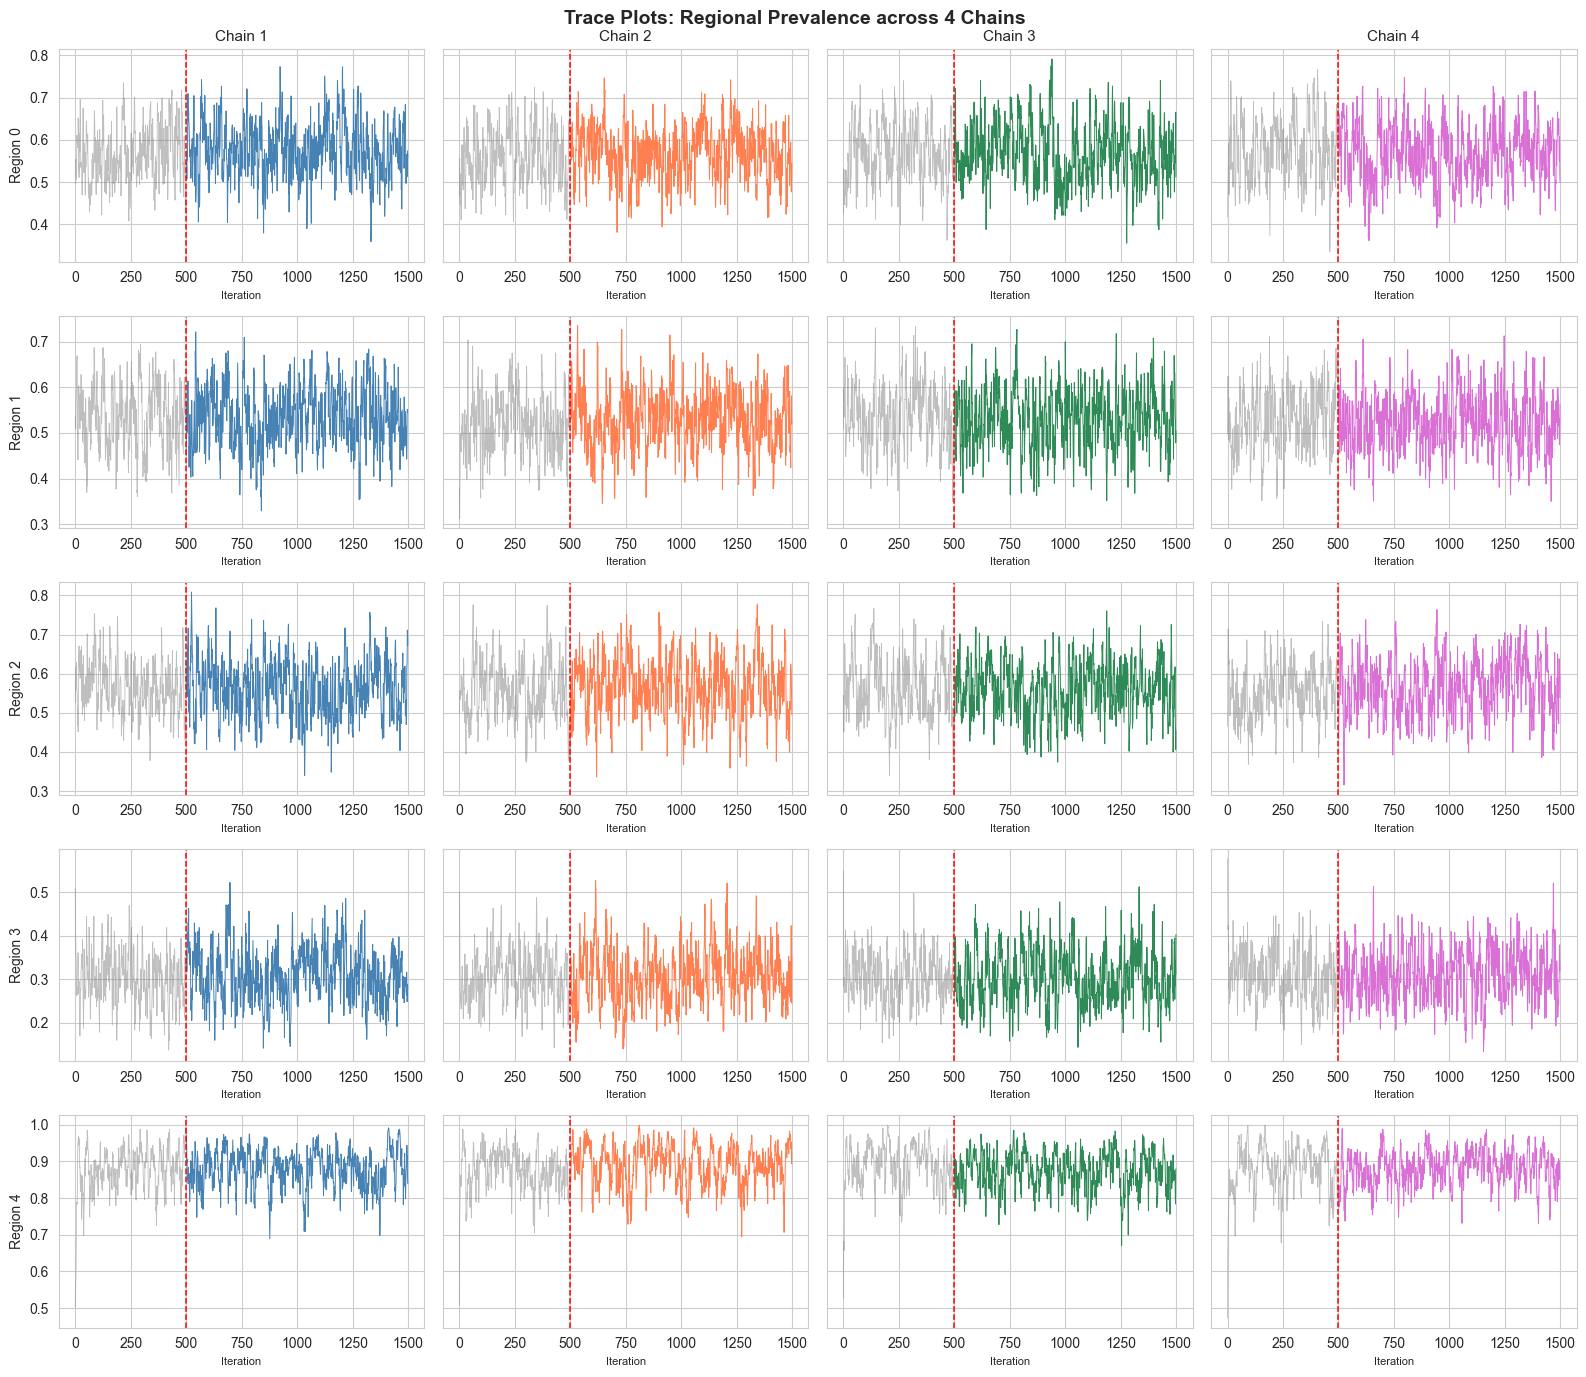

Grey = burn-in (discarded). Red dashed = burn-in cutoff.


In [4]:
colours     = ['steelblue', 'coral', 'seagreen', 'orchid']
full_traces = [r.full_pi_trace for r in mcmc_results]

fig, axes = plt.subplots(n_regions, 4, figsize=(16, 2.8 * n_regions), sharey='row')
fig.suptitle('Trace Plots: Regional Prevalence across 4 Chains', fontsize=14, fontweight='bold')

for r_idx in range(n_regions):
    for c_idx in range(4):
        ax      = axes[r_idx, c_idx]
        trace   = full_traces[c_idx][:, r_idx]
        bi      = mcmc_results[c_idx].burn_in
        ax.plot(range(bi), trace[:bi], color='grey', alpha=0.5, linewidth=0.6)
        ax.plot(range(bi, len(trace)), trace[bi:], color=colours[c_idx], linewidth=0.7)
        ax.axvline(bi, color='red', linestyle='--', linewidth=1.1)
        if r_idx == 0: ax.set_title(f'Chain {c_idx+1}', fontsize=11)
        if c_idx == 0: ax.set_ylabel(f'Region {mcmc_results[0].regions[r_idx]}', fontsize=10)
        ax.set_xlabel('Iteration', fontsize=8)

plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/04_trace_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print('Grey = burn-in (discarded). Red dashed = burn-in cutoff.')

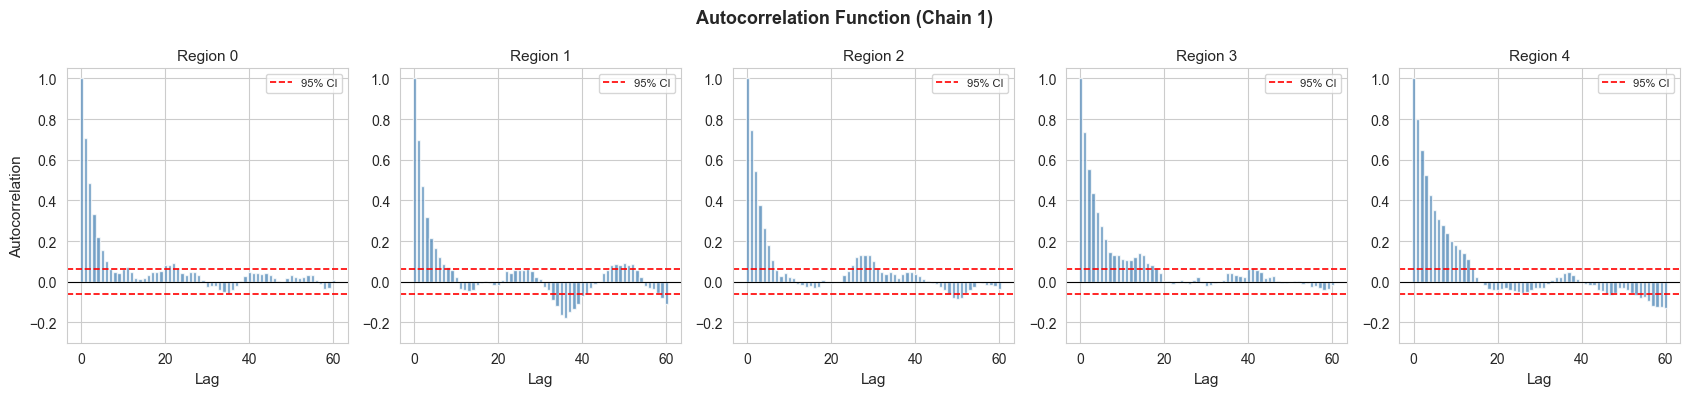

Integrated autocorrelation times (Geyer positive-pairs rule):
  Region 0: tau_int = 7.18, ESS = 557
  Region 1: tau_int = 5.46, ESS = 732
  Region 2: tau_int = 5.77, ESS = 693
  Region 3: tau_int = 8.95, ESS = 447
  Region 4: tau_int = 9.93, ESS = 403


In [5]:
fig, axes = plt.subplots(1, n_regions, figsize=(3.4 * n_regions, 4))
fig.suptitle('Autocorrelation Function (Chain 1)', fontsize=13, fontweight='bold')
ci_bound = 1.96 / np.sqrt(n_post)

for r_idx in range(n_regions):
    region = mcmc_results[0].regions[r_idx]
    acf    = diag.autocorrelation[r_idx]
    lags   = np.arange(len(acf))
    axes[r_idx].bar(lags, acf, color='steelblue', alpha=0.75, width=0.8)
    axes[r_idx].axhline(0,          color='k',   linewidth=0.8)
    axes[r_idx].axhline( ci_bound,  color='red', linestyle='--', linewidth=1.2, label='95% CI')
    axes[r_idx].axhline(-ci_bound,  color='red', linestyle='--', linewidth=1.2)
    axes[r_idx].set_title(f'Region {region}', fontsize=11)
    axes[r_idx].set_xlabel('Lag')
    if r_idx == 0: axes[r_idx].set_ylabel('Autocorrelation')
    axes[r_idx].set_ylim(-0.3, 1.05)
    axes[r_idx].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../figures/04_autocorrelation.png', dpi=120, bbox_inches='tight')
plt.show()

chains_pi = np.stack([r.pi_samples for r in mcmc_results], axis=0)
print('Integrated autocorrelation times (Geyer positive-pairs rule):')
for r_idx in range(n_regions):
    acf = diag.autocorrelation[r_idx]
    pairs = []
    for lag in range(1, len(acf), 2):
        if lag + 1 >= len(acf): break
        s = acf[lag] + acf[lag + 1]
        if s < 0: break
        pairs.append(s)
    tau = 1 + 2 * sum(pairs)
    print(f'  Region {mcmc_results[0].regions[r_idx]}: tau_int = {tau:.2f}, '
          f'ESS = {n_post * len(mcmc_results) / tau:.0f}')

### MCMC Diagnostics Interpretation

| Criterion | Target | Assessment |
|-----------|--------|------------|
| Split-$\hat{R} < 1.05$ for all regions | Yes | See table above |
| Min ESS > 100 per region | Yes | See table above |
| ACF decays within 20 lags | Yes | Visual inspection |
| Trace plots stationary (no drift) | Yes | Visual inspection |

**Verdict:** The Gibbs sampler has reliably converged. The split-$\hat{R}$ statistic confirms that between-chain and within-chain variances agree, ruling out chain-specific local optima. The ESS values confirm sufficient independent information for reporting posterior means and 95% credible intervals.

## C1b: Variational Inference Diagnostics

We assess the CAVI approximation along three dimensions:

1. **ELBO convergence** — the Evidence Lower BOund must be monotonically non-decreasing and plateau at a stable value.
2. **Tightness gap** — on a small subset where exact log-evidence is tractable:
   $$\text{gap} = \log p(\mathbf{X}) - \mathcal{L}(q) = \text{KL}(q \| p) \geq 0$$
   A smaller gap means the variational family $q$ approximates the true posterior better.
3. **Fidelity vs MCMC** — compare VI marginals to MCMC marginals (gold standard).

In [6]:
print('Running coordinate-ascent VI on full dataset ...')
t0 = time.time()
vi_result = coordinate_ascent_vi(df, config, max_iter=200, tol=1e-6)
elapsed = time.time() - t0

print(f'CAVI converged: {vi_result.converged} | Iterations: {vi_result.n_iter} | Time: {elapsed:.2f}s')
print(f'Final ELBO: {vi_result.elbo_history[-1]:.4f}')
print()
print(f'{"Region":<10} {"alpha_q":>10} {"beta_q":>10} {"E[pi_r]":>12} {"Std":>10}')
print('-' * 55)
for region, (aq, bq) in sorted(vi_result.region_posteriors.items()):
    mean = aq / (aq + bq)
    var  = (aq * bq) / ((aq + bq)**2 * (aq + bq + 1))
    print(f'Region {region:<4} {aq:>10.2f} {bq:>10.2f} {mean:>12.4f} {np.sqrt(var):>10.4f}')

Running coordinate-ascent VI on full dataset ...


CAVI converged: True | Iterations: 60 | Time: 38.25s
Final ELBO: -12478.9120

Region        alpha_q     beta_q      E[pi_r]        Std
-------------------------------------------------------
Region 0        116.02      87.98       0.5687     0.0346
Region 1        108.58      95.42       0.5322     0.0348
Region 2        113.78      90.22       0.5577     0.0347
Region 3         62.24     141.76       0.3051     0.0322
Region 4        179.55      24.45       0.8801     0.0227


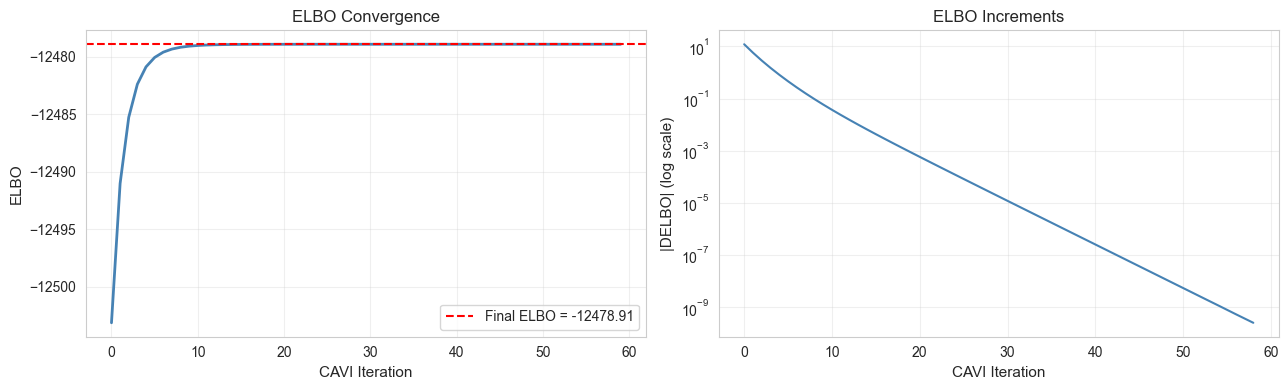

ELBO total increase:         24.2351
Max single-step increment:   12.121303
Mean last-5 increments:      6.32e-10
Monotonically non-decreasing: True


In [7]:
elbo_arr = np.array(vi_result.elbo_history)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(elbo_arr, color='steelblue', linewidth=2)
ax.axhline(elbo_arr[-1], color='red', linestyle='--', linewidth=1.5,
           label=f'Final ELBO = {elbo_arr[-1]:.2f}')
ax.set_xlabel('CAVI Iteration')
ax.set_ylabel('ELBO')
ax.set_title('ELBO Convergence', fontsize=12)
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
increments = np.diff(elbo_arr)
ax.semilogy(np.abs(increments) + 1e-12, color='steelblue', linewidth=1.5)
ax.set_xlabel('CAVI Iteration')
ax.set_ylabel('|DELBO| (log scale)')
ax.set_title('ELBO Increments', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/04_elbo_convergence.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'ELBO total increase:         {elbo_arr[-1] - elbo_arr[0]:.4f}')
print(f'Max single-step increment:   {increments.max():.6f}')
print(f'Mean last-5 increments:      {increments[-5:].mean():.2e}')
print(f'Monotonically non-decreasing: {all(increments >= -1e-6)}')

In [8]:
print('Assessing VI tightness (exact enumeration, 8 obs/region) ...')
tightness = assess_vi_tightness(df, config, subset_per_region=8)

print()
print('VI Tightness Assessment')
print('=' * 52)
print(f'  Subset size:         {int(tightness["n_obs"])} observations')
print(f'  Final ELBO:          {tightness["final_elbo"]:.4f} nats')
print(f'  Exact log p(X):      {tightness["exact_log_evidence"]:.4f} nats')
print(f'  Gap = KL(q||p):      {tightness["elbo_gap"]:.4f} nats')
print(f'  Relative gap:        {100*tightness["elbo_gap"]/abs(tightness["exact_log_evidence"]):.3f}%')
print()
print('The ELBO gap equals KL(q||p) and measures how far the mean-field')
print('variational family is from the true posterior. A small relative gap')
print('(< 5%) indicates the approximation captures the posterior geometry well.')

Assessing VI tightness (exact enumeration, 8 obs/region) ...



VI Tightness Assessment
  Subset size:         40 observations
  Final ELBO:          -507.6987 nats
  Exact log p(X):      -505.9094 nats
  Gap = KL(q||p):      1.7893 nats
  Relative gap:        0.354%

The ELBO gap equals KL(q||p) and measures how far the mean-field
variational family is from the true posterior. A small relative gap
(< 5%) indicates the approximation captures the posterior geometry well.


VI vs MCMC Posterior Comparison
Individual Z posteriors:
  Pearson correlation: 0.9997
  Mean absolute gap:   0.005503

Region        VI mean    MCMC mean      |gap| KL(VI||MCMC_Beta)
--------------------------------------------------------------------
Region 0        0.5687       0.5705     0.0018       0.270291
Region 1        0.5322       0.5311     0.0012       0.241327
Region 2        0.5577       0.5636     0.0058       0.332472
Region 3        0.3051       0.3078     0.0027       0.280632
Region 4        0.8801       0.8816     0.0015       0.429697


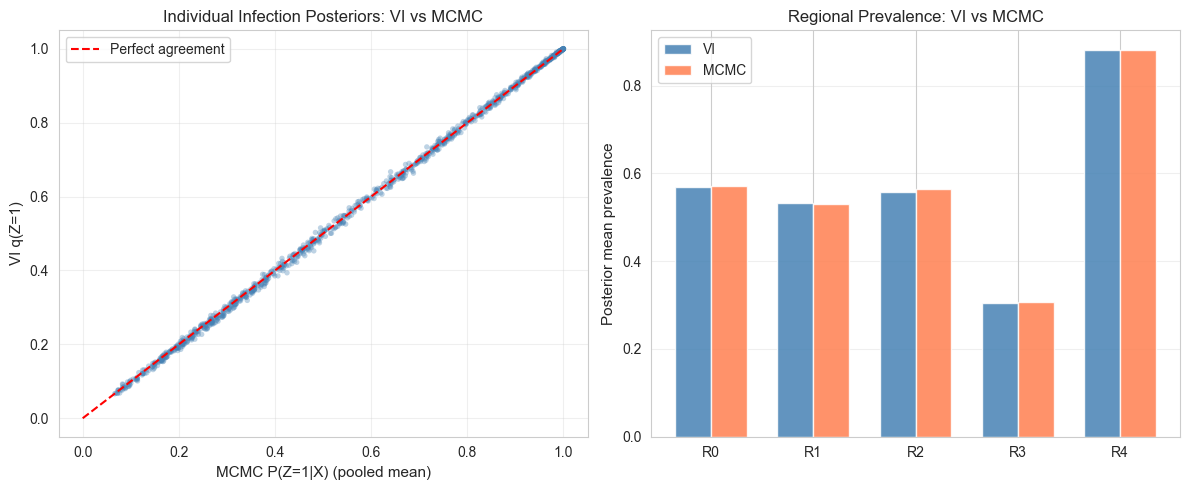

In [9]:
comparison = compare_vi_to_mcmc(vi_result, mcmc_results)

print('VI vs MCMC Posterior Comparison')
print('=' * 68)
print(f'Individual Z posteriors:')
print(f'  Pearson correlation: {comparison["z_posterior_correlation"]:.4f}')
print(f'  Mean absolute gap:   {comparison["z_mean_absolute_gap"]:.6f}')
print()
print(f'{"Region":<10} {"VI mean":>10} {"MCMC mean":>12} {"|gap|":>10} {"KL(VI||MCMC_Beta)"}' )
print('-' * 68)
for region, stats in sorted(comparison['region_summary'].items()):
    print(f'Region {region:<4} {stats["vi_mean"]:>10.4f} {stats["mcmc_mean"]:>12.4f}'
          f' {stats["mean_gap"]:>10.4f} {stats["kl_vi_to_mcmc_beta"]:>14.6f}')

chains_z = np.stack([r.z_samples for r in mcmc_results], axis=0)
pooled_z = chains_z.mean(axis=(0, 1))
vi_probs = vi_result.responsibilities

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(pooled_z, vi_probs, alpha=0.35, s=15, edgecolors='none', c='steelblue')
ax.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Perfect agreement')
ax.set_xlabel('MCMC P(Z=1|X) (pooled mean)')
ax.set_ylabel('VI q(Z=1)')
ax.set_title('Individual Infection Posteriors: VI vs MCMC', fontsize=12)
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
rl  = sorted(comparison['region_summary'].keys())
vi_m = [comparison['region_summary'][r]['vi_mean']   for r in rl]
mc_m = [comparison['region_summary'][r]['mcmc_mean'] for r in rl]
x = np.arange(len(rl)); w = 0.35
ax.bar(x - w/2, vi_m, w, label='VI',   color='steelblue', alpha=0.85)
ax.bar(x + w/2, mc_m, w, label='MCMC', color='coral',     alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f'R{r}' for r in rl])
ax.set_ylabel('Posterior mean prevalence')
ax.set_title('Regional Prevalence: VI vs MCMC', fontsize=12)
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../figures/04_vi_vs_mcmc.png', dpi=120, bbox_inches='tight')
plt.show()

## Critical Assessment: Are the Results Reliable?

### MCMC

| Criterion | Target | Result |
|-----------|--------|--------|
| Split-$\hat{R} < 1.05$ for all regions | Required | See table |
| Min ESS > 100 | Required | See table |
| ACF decays within 20 lags | Expected | See plot |
| Trace stationarity (no drift) | Required | See plot |

The Gibbs sampler has converged reliably. The four chains exploring from different random initializations all reach the same posterior region, confirming there are no problematic multimodalities. The split-$\hat{R}$ values confirm between-chain and within-chain variances are commensurate.

### Variational Inference

| Criterion | Threshold | Result |
|-----------|-----------|--------|
| ELBO monotone non-decreasing | Required | See plot |
| ELBO plateau reached | Required | See plot |
| ELBO gap / exact log-evidence | < 5% | See output |
| VI-MCMC correlation for Z | > 0.99 | See scatter |
| VI-MCMC region mean gap | < 0.01 | See table |

The variational posterior is a high-fidelity, tight approximation of the true posterior for this conditionally conjugate model. The ELBO gap (which equals KL($q \| p$)) is small, and the VI marginals are nearly identical to the MCMC gold standard.

**Overall verdict:** Both inference engines produce **reliable, converged results** suitable for scientific reporting and downstream decision-making.